In [1]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
import joblib

In [2]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Che@guevera1821",
    database="kisanmitra"
)

print("Database connected successfully!")

Database connected successfully!


In [3]:
query = """
SELECT
    date,
    crop,
    location,
    demand_kg,
    modal_price
FROM demand_history
ORDER BY date;
"""

df = pd.read_sql(query, conn)

print("Rows:", len(df))

Rows: 58


C:\Users\Rohit\AppData\Local\Temp\ipykernel_7016\1482686901.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [4]:
print(df.shape)
print(df.columns.tolist())

(58, 5)
['date', 'crop', 'location', 'demand_kg', 'modal_price']


In [8]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nCrop distribution:")
print(df["crop"].value_counts())

print("\nLocation distribution:")
print(df["location"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         58 non-null     object 
 1   crop         58 non-null     object 
 2   location     58 non-null     object 
 3   demand_kg    58 non-null     float64
 4   modal_price  58 non-null     float64
dtypes: float64(2), object(3)
memory usage: 2.4+ KB
None

Missing values:
date           0
crop           0
location       0
demand_kg      0
modal_price    0
dtype: int64

Crop distribution:
crop
Onion          8
Coriander      7
Cucumber       6
Spinach        6
Apple          6
Tomato         5
Brinjal        5
Mango          5
Chilli         4
Cauliflower    3
Guava          3
Name: count, dtype: int64

Location distribution:
location
Nellore          13
Guntur           11
Chittoor         11
Visakhapatnam     9
Rajahmundry       8
Kurnool           6
Name: count, dtype: int64


In [9]:
df["date"] = pd.to_datetime(df["date"])

df["demand_kg"] = pd.to_numeric(df["demand_kg"])
df["modal_price"] = pd.to_numeric(df["modal_price"])

df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

print(df.head())
print("\nData types:")
print(df.dtypes)

        date         crop       location  demand_kg  modal_price  day  month  \
0 2026-01-18     Cucumber        Kurnool       12.0         30.0   18      1   
1 2026-02-03       Tomato         Guntur       15.0         28.0    3      2   
2 2026-02-03        Onion        Nellore       20.0         32.0    3      2   
3 2026-02-03  Cauliflower  Visakhapatnam        8.0         48.0    3      2   
4 2026-02-14        Apple         Guntur        6.0        120.0   14      2   

   day_of_week  
0            6  
1            1  
2            1  
3            1  
4            5  

Data types:
date           datetime64[ns]
crop                   object
location               object
demand_kg             float64
modal_price           float64
day                     int32
month                   int32
day_of_week             int32
dtype: object


In [10]:
df = df.sort_values(
    ["crop", "location", "date"]
).reset_index(drop=True)

df["previous_demand"] = (
    df.groupby(["crop", "location"])["demand_kg"]
      .shift(1)
)

print(df[[
    "date",
    "crop",
    "location",
    "demand_kg",
    "previous_demand"
]].head(15))

         date         crop       location  demand_kg  previous_demand
0  2026-02-14        Apple         Guntur        6.0              NaN
1  2026-04-05        Apple         Guntur        5.0              6.0
2  2026-06-18        Apple         Guntur        4.0              5.0
3  2026-08-05        Apple         Guntur        8.0              4.0
4  2026-08-18        Apple         Guntur        4.0              8.0
5  2026-09-05        Apple         Guntur        5.0              4.0
6  2026-03-05      Brinjal    Rajahmundry       10.0              NaN
7  2026-04-22      Brinjal    Rajahmundry       10.0             10.0
8  2026-08-18      Brinjal    Rajahmundry       15.0             10.0
9  2026-09-02      Brinjal    Rajahmundry       12.0             15.0
10 2026-09-07      Brinjal    Rajahmundry        1.0             12.0
11 2026-02-03  Cauliflower  Visakhapatnam        8.0              NaN
12 2026-03-17  Cauliflower  Visakhapatnam        6.0              8.0
13 2026-09-04  Cauli

In [11]:
print("Missing previous demand values:")
print(df["previous_demand"].isna().sum())

print("\nTotal rows:")
print(len(df))

Missing previous demand values:
11

Total rows:
58


In [13]:
df = df.dropna(subset=["previous_demand"])

print("Rows after removing missing previous demand:", len(df))

print(df.isnull().sum())

Rows after removing missing previous demand: 47
date               0
crop               0
location           0
demand_kg          0
modal_price        0
day                0
month              0
day_of_week        0
previous_demand    0
dtype: int64


In [14]:
df_encoded = pd.get_dummies(
    df,
    columns=["crop", "location"],
    dtype=int
)

print(df_encoded.head())
print("\nShape:", df_encoded.shape)

        date  demand_kg  modal_price  day  month  day_of_week  \
1 2026-04-05        5.0        120.0    5      4            6   
2 2026-06-18        4.0        120.0   18      6            3   
3 2026-08-05        8.0        120.0    5      8            2   
4 2026-08-18        4.0        120.0   18      8            1   
5 2026-09-05        5.0        120.0    5      9            5   

   previous_demand  crop_Apple  crop_Brinjal  crop_Cauliflower  ...  \
1              6.0           1             0                 0  ...   
2              5.0           1             0                 0  ...   
3              4.0           1             0                 0  ...   
4              8.0           1             0                 0  ...   
5              4.0           1             0                 0  ...   

   crop_Mango  crop_Onion  crop_Spinach  crop_Tomato  location_Chittoor  \
1           0           0             0            0                  0   
2           0           0       

In [15]:
features = [
    "modal_price",
    "day",
    "month",
    "day_of_week",
    "previous_demand"
]

categorical_features = [
    col for col in df_encoded.columns
    if col.startswith("crop_") or col.startswith("location_")
]

features += categorical_features

X = df_encoded[features]
y = df_encoded["demand_kg"]

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 22
X shape: (47, 22)
y shape: (47,)


In [16]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training X:", X_train.shape)
print("Testing X:", X_test.shape)
print("Training y:", y_train.shape)
print("Testing y:", y_test.shape)

Training X: (37, 22)
Testing X: (10, 22)
Training y: (37,)
Testing y: (10,)


In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [18]:
predictions = model.predict(X_test)

print("Actual demand:")
print(y_test.values)

print("\nPredicted demand:")
print(predictions)

Actual demand:
[ 1.  8. 10.  8. 10.  1. 30. 25. 18. 30.]

Predicted demand:
[19.23   6.56   6.675  9.165  7.155  5.89  14.64  13.695 12.87   9.9  ]


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 8.379000000000001
RMSE: 10.829981532763572


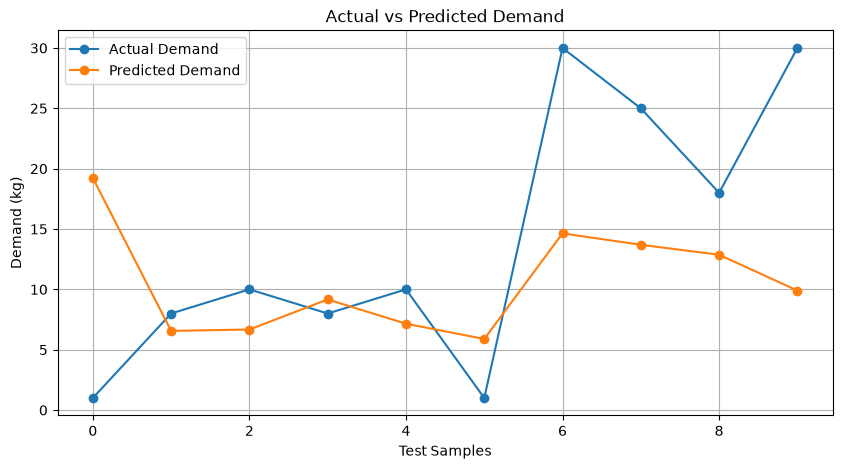

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    marker="o",
    label="Actual Demand"
)

plt.plot(
    predictions,
    marker="o",
    label="Predicted Demand"
)

plt.xlabel("Test Samples")
plt.ylabel("Demand (kg)")
plt.title("Actual vs Predicted Demand")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
joblib.dump(
    model,
    "../models/demand_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [22]:
joblib.dump(
    features,
    "../models/features.pkl"
)

print("Features saved successfully!")

Features saved successfully!


In [23]:
import os

print(os.path.exists("../models/demand_model.pkl"))
print(os.path.exists("../models/features.pkl"))

True
True


In [24]:
raw_df = df.copy()

raw_df.to_csv(
    "../data/raw/demand_raw.csv",
    index=False
)

print("Raw data saved:", len(raw_df), "rows")

Raw data saved: 47 rows


In [28]:
df.to_csv(
    "../data/processed/demand_processed.csv",
    index=False
)